# Challenge 2: Image Classification

## Hyperparameters

In [165]:

# -------------------------
# Reproducibility
# -------------------------
SEED = 400

# -------------------------
# Data & splitting
# -------------------------
PATCHES_DIR       = "patches"
PATCH_LABEL_CSV   = "label_patches.csv"
TEST_PATCHES_DIR  = "test_patches"
TEST_PATCH_CSV    = "test_patches.csv"
VALIDATION_SIZE   = 0.15       

USE_MASKED_IMAGES = False       # masked vs raw patches
BATCH_SIZE        = 64

# -------------------------
# Normalization & Augmentation
# -------------------------
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

ROTATION_DEG          = 180
HFLIP_P               = 0.5
VFLIP_P               = 0.5
COLORJITTER_BRIGHTNESS = 0.1
COLORJITTER_CONTRAST   = 0.1
COLORJITTER_SATURATION = 0.1
COLORJITTER_HUE        = 0.05

# -------------------------
# MixUp / CutMix
# -------------------------
USE_MIXUP_CUTMIX = True
MIXUP_PROB       = 0.5
MIXUP_ALPHA      = 1.0
CUTMIX_ALPHA     = 1.0
MAX_NORM         = None        # gradient clipping (None = disabled)

# -------------------------
# Loss regularization
# -------------------------
L1_LAMBDA = 0.0
L2_LAMBDA = 0.0

# -------------------------
# Training schedule
# -------------------------
WARMUP_EPOCHS      = 20
FINETUNE_EPOCHS    = 300
PATIENCE_WARMUP    = 5
PATIENCE_FINETUNE  = 100

LR_WARMUP              = 1e-3
LR_FINETUNE            = 1e-4
WEIGHT_DECAY_WARMUP    = 1e-2
WEIGHT_DECAY_FINETUNE  = 1e-2
T_MAX_SCHEDULER        = 300      # CosineAnnealingLR T_max

# -------------------------
# Model / head config (ResNet18)
# -------------------------
USE_MLP_HEAD     = True
MLP_HEAD_HIDDEN1 = 16
MLP_HEAD_HIDDEN2 = 16
MLP_DROPOUT1     = 0.4
MLP_DROPOUT2     = 0.3

# Which parts of ResNet to unfreeze in fine‑tuning
LAYERS_TO_UNFREEZE = ["layer4", "classifier"]

# -------------------------
# Grad-CAM & plotting
# -------------------------
GRADCAM_NUM_SAMPLES_VAL  = 8
GRADCAM_NUM_SAMPLES_TEST = 8
GRADCAM_TARGET_LAYER     = "layer3"

PLOT_FLAG    = True
MODEL_DIR    = "models"
SUBMIT_DIR   = "submissions"


## Module imports

In [166]:
import cplot

import os
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchview import draw_graph
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import numpy as np
import csv
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.cm as cm  
import random
import math




if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

np.random.seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")




PyTorch version: 2.9.1+cu128
Device: cuda


## Image and Label Loader

In [167]:
def get_whitelisted_ids(whitelist_path):
    if not whitelist_path or not os.path.exists(whitelist_path):
        return None
    ids = set()
    with open(whitelist_path, 'r') as f:
        for line in f:
            if line.strip():
                parts = line.strip().split('_')
                if len(parts) > 1:
                    ids.add(parts[1].split('.')[0])
    return sorted(list(ids), key=int)


In [168]:
def load_labels_aligned(csv_path, filtered_ids_list):
    print(f"Loading labels for {len(filtered_ids_list)} filtered images...")
    df = pd.read_csv(csv_path)
    id_col = df.columns[0]
    label_col = df.columns[1]
    df['clean_id'] = df[id_col].astype(str).apply(lambda x: x.split('_')[1].split('.')[0] if '_' in x else x)
    label_map = dict(zip(df['clean_id'], df[label_col]))
    
    final_labels = []
    for uid in filtered_ids_list:
        if uid in label_map:
            final_labels.append(label_map[uid])
        else:
            raise ValueError(f"Label missing for ID {uid}")
    return np.array(final_labels)

In [169]:
def get_sorted_filenames(folder):
    ids = set()
    for f in os.listdir(folder):
        if f.startswith("img_") and f.endswith(".png"): ids.add(f.split('_')[1].split('.')[0])
    return [f"img_{i}.png" for i in sorted(list(ids), key=int)]

## Data Augmentation

In [170]:
import cv2
import torch
import torch.nn as nn
import torchstain

class MacenkoTransform(nn.Module):
    def __init__(self, ref_path, intensity_th=0.8):
        super().__init__()
        # Load reference image as RGB uint8 (H, W, 3)
        ref_bgr = cv2.imread(ref_path)
        if ref_bgr is None:
            raise ValueError(f"Could not read reference image at {ref_path}")
        ref_rgb = cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2RGB)
        ref_t = torch.from_numpy(ref_rgb).permute(2, 0, 1).to(torch.uint8)  # (3, H, W)

        self.normalizer = torchstain.normalizers.MacenkoNormalizer(backend='torch')
        self.normalizer.fit(ref_t)  # expects (C, H, W)
        self.intensity_th = intensity_th

    def forward(self, img):
        """
        img: (C, H, W) or (B, C, H, W), values in [0,1] or [0,255]
        Returns: same shape, but stain-normalized, float in [0,1]
        """
        single = (img.ndim == 3)
        if single:
            img = img.unsqueeze(0)  # -> (1, C, H, W)

        out_list = []
        for x in img:  # x: (C, H, W)
            # to uint8 [0,255]
            x_np = x.permute(1, 2, 0).cpu().numpy()  # (H, W, C)
            if x_np.max() <= 1.0:
                x_np = (x_np * 255).astype("uint8")
            else:
                x_np = x_np.astype("uint8")

            x_t = torch.from_numpy(x_np).permute(2, 0, 1).to(torch.uint8)  # (C, H, W)

            # torchstain returns (I_norm, H, E) or similar
            norm_out = self.normalizer.normalize(x_t)
            if isinstance(norm_out, (tuple, list)):
                norm_t = norm_out[0]
            else:
                norm_t = norm_out

            # Ensure we are (C, H, W)
            if norm_t.ndim == 3 and norm_t.shape[0] != 3 and norm_t.shape[-1] == 3:
                norm_t = norm_t.permute(2, 0, 1)  # (H, W, 3) -> (3, H, W)

            norm_t = norm_t.float() / 255.0      # [0,1] float
            out_list.append(norm_t)

        out = torch.stack(out_list).to(img.device)  # (B, C, H, W)
        return out[0] if single else out


In [171]:
from torchvision.transforms import v2 as transforms

norm_mean = NORM_MEAN
norm_std  = NORM_STD

train_transforms = transforms.Compose([
    transforms.RandomRotation(ROTATION_DEG),
    transforms.RandomHorizontalFlip(p=HFLIP_P),
    transforms.RandomVerticalFlip(p=VFLIP_P),
    transforms.ColorJitter(
        brightness=COLORJITTER_BRIGHTNESS,
        contrast=COLORJITTER_CONTRAST,
        saturation=COLORJITTER_SATURATION,
        hue=COLORJITTER_HUE,
    ),
    transforms.Normalize(mean=norm_mean, std=norm_std),
])

val_transforms = transforms.Compose([
    transforms.Normalize(mean=norm_mean, std=norm_std),
])

test_transforms = transforms.Compose([
    transforms.Normalize(mean=norm_mean, std=norm_std),
])

# 1. SETUP: Visualization (Fix Color, No Standard Norm)
vis_transforms = transforms.Compose([
    transforms.ToTensor(),
    #macenko
])

print("Transforms Initialized. Corrected pipeline order: ToTensor -> Macenko -> Augs -> Normalize.")

Transforms Initialized. Corrected pipeline order: ToTensor -> Macenko -> Augs -> Normalize.


/home/dev/.pyenv/versions/ml/lib/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [172]:
import numpy as np
import torch.nn.functional as F

def mixup_batch(x, y, alpha=0.4):
    """MixUp on a batch: returns mixed images and (y_a, y_b, lam)."""
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def rand_bbox(size, lam):
    """Random bounding box for CutMix."""
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    return x1, y1, x2, y2

def cutmix_batch(x, y, alpha=1.0):
    """CutMix on a batch: returns mixed images and (y_a, y_b, lam)."""
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)

    shuffled_x = x[index]
    y_a, y_b = y, y[index]

    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    x[:, :, y1:y2, x1:x2] = shuffled_x[:, :, y1:y2, x1:x2]

    lam = 1.0 - ((x2 - x1) * (y2 - y1) / (x.size(-1) * x.size(-2)))
    return x, y_a, y_b, lam

def apply_mixup_cutmix(x, y, prob=0.7, mixup_alpha=0.4, cutmix_alpha=1.0):
    """Randomly apply MixUp or CutMix with total probability `prob`."""
    if np.random.rand() > prob:
        return x, y, y, 1.0  # no augmentation

    if np.random.rand() < 0.5:
        return mixup_batch(x, y, alpha=mixup_alpha)
    else:
        return cutmix_batch(x, y, alpha=cutmix_alpha)


## Dataloader creation

In [173]:
import os
import cv2
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as tv_transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


class PatchDataset(Dataset):
    def __init__(self, csv_path, root_dir, label_encoder, transform=None, use_masked_img=True):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.le = label_encoder
        self.transform = transform          # this will now be ONLY ToTensor
        self.use_masked_img = use_masked_img
        self.df["label_id"] = self.le.transform(self.df["label"])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["patch_filename"]

        if self.use_masked_img:
            if not filename.startswith("masked_"):
                filename = filename.replace("img_", "masked_img_")
        else:
            if filename.startswith("masked_"):
                filename = filename.replace("masked_img_", "img_")

        img_path = os.path.join(self.root_dir, filename)
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            raise ValueError(f"Could not read patch {img_path}.")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)

        if self.transform is not None:
            img = self.transform(img_pil)
        else:
            img = tv_transforms.ToTensor()(img_pil)

        label = int(row["label_id"])
        return img, label



# ----------------------------------------------------
# PREPARATION & LOADERS
# ----------------------------------------------------
df_patches = pd.read_csv(PATCH_LABEL_CSV)
labels_str = df_patches["label"].values

label_encoder = LabelEncoder()
label_encoder.fit(labels_str)
NUM_CLASSES = len(label_encoder.classes_)

# Extract ID for Stratification (Works for both 'img_' and 'masked_img_')
df_patches["img_id"] = df_patches["patch_filename"].str.extract(r"(\d+)_y")[0]

img_ids = df_patches["img_id"].unique()
img_id_to_label = df_patches.groupby("img_id")["label"].first().to_dict()
img_labels = np.array([img_id_to_label[i] for i in img_ids])

train_img_ids, val_img_ids = train_test_split(
    img_ids, test_size=VALIDATION_SIZE, stratify=img_labels, random_state=42
)

df_patches_train = df_patches[df_patches["img_id"].isin(train_img_ids)].reset_index(drop=True)
df_patches_val   = df_patches[df_patches["img_id"].isin(val_img_ids)].reset_index(drop=True)

patch_train_csv = "label_patches_train.csv"
patch_val_csv   = "label_patches_val.csv"
df_patches_train.to_csv(patch_train_csv, index=False)
df_patches_val.to_csv(patch_val_csv, index=False)

cpu_to_tensor = tv_transforms.ToTensor()

train_ds = PatchDataset(
    patch_train_csv,
    PATCHES_DIR,
    label_encoder,
    transform=cpu_to_tensor,      
    use_masked_img=USE_MASKED_IMAGES,
)

val_ds = PatchDataset(
    patch_val_csv,
    PATCHES_DIR,
    label_encoder,
    transform=cpu_to_tensor,      
    use_masked_img=USE_MASKED_IMAGES,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train size: {len(train_ds)} | Val size: {len(val_ds)}")
print(f"Currently using: {'MASKED (Blackout)' if USE_MASKED_IMAGES else 'RAW (Standard)'} images.")

Train size: 1794 | Val size: 267
Currently using: RAW (Standard) images.


In [174]:
import pandas as pd

# 1. Re-extract IDs using the ROBUST regex (Works for 'img_' and 'masked_img_')
#    We look for the digits strictly before the "_y" coordinate.
train_ids = df_patches_train["patch_filename"].str.extract(r"(\d+)_y")[0].unique()
val_ids   = df_patches_val["patch_filename"].str.extract(r"(\d+)_y")[0].unique()

# 2. Convert to Python Sets
set_train = set(train_ids)
set_val   = set(val_ids)

# 3. Calculate Intersection (Overlap)
overlap = set_train.intersection(set_val)

print(f"Corrected Counts:")
print(f"Unique Train Images: {len(set_train)}")
print(f"Unique Val Images:   {len(set_val)}")
print("-" * 30)

if len(overlap) > 0:
    print(f"CRITICAL LEAKAGE DETECTED!")
    print(f"These {len(overlap)} Images are in BOTH sets:")
    print(list(overlap))
    
    print("\nSUGGESTED FIX:")
    print("Make sure you split 'img_ids' (the unique list), NOT the dataframe itself.")
else:
    print(f"DATA SPLIT IS CLEAN.")
    print("There is NO overlap between Train and Validation patients.")

Corrected Counts:
Unique Train Images: 493
Unique Val Images:   88
------------------------------
DATA SPLIT IS CLEAN.
There is NO overlap between Train and Validation patients.


### Plots

Visualizing distribution of 2061 generated patches...


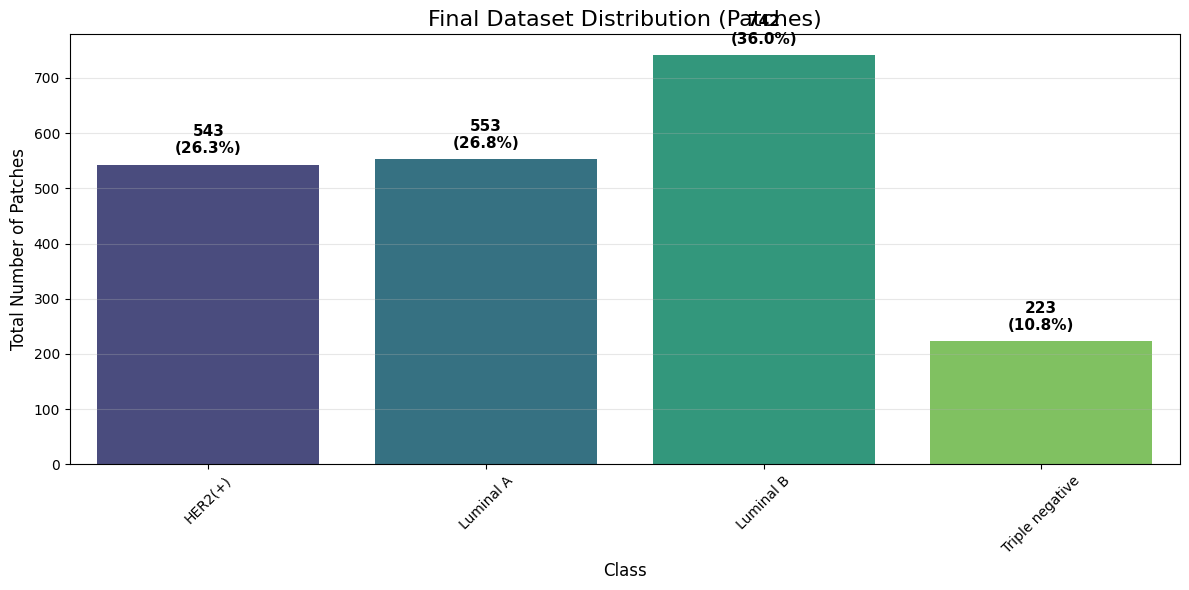

In [175]:
def plot_patch_distribution(labels, title="Final Dataset Distribution (Patches)"):

    # 1. Count classes
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    # 2. Setup Plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=unique_labels, y=counts, palette='viridis',
                     hue=unique_labels, legend=False)
    
    # 3. Styling
    plt.title(title, fontsize=16)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Total Number of Patches", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # 4. Add count labels on top of bars
    total_patches = int(counts.sum())
    for i, v in enumerate(counts):
        percentage = (v / total_patches) * 100
        ax.text(i, v + (max(counts) * 0.02),
                f"{v}\n({percentage:.1f}%)",
                ha='center', va='bottom',
                fontweight='bold', fontsize=11)
        
    plt.tight_layout()
    plt.show()


# Load patch labels from the new CSV and plot
df_patches = pd.read_csv(PATCH_LABEL_CSV)  # "challenge2/label_patches.csv"
labels = df_patches["label"].values

print(f"Visualizing distribution of {len(labels)} generated patches...")
plot_patch_distribution(labels)


Train images: 493, Val images: 88
Train patches: 1794, Val patches: 267
----------------------------------------
Visualizing actual tensors entering the model...


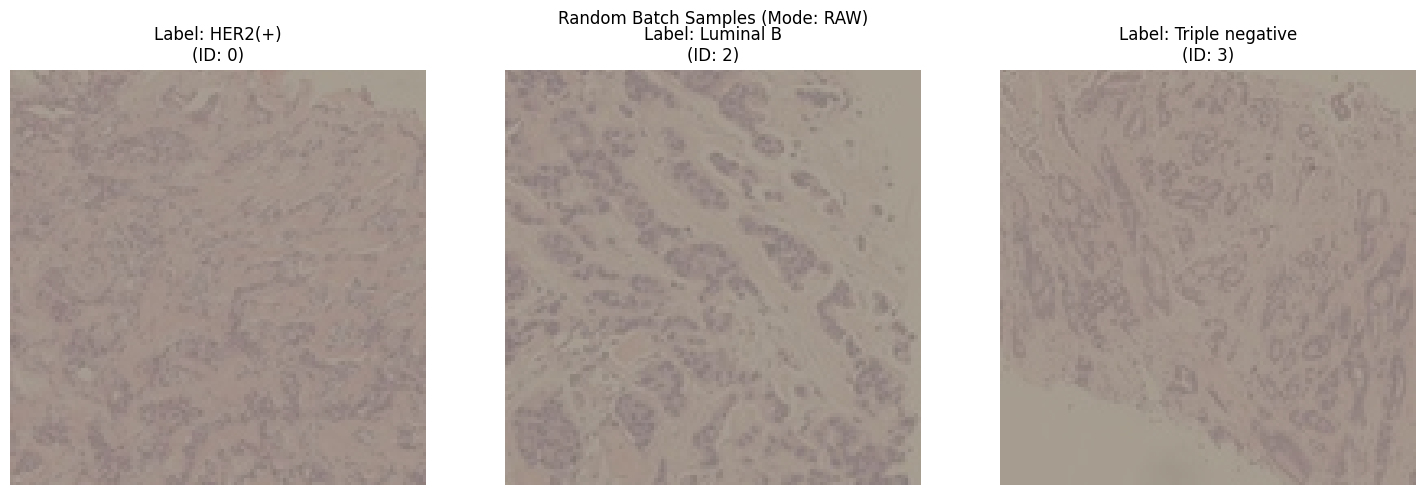

In [176]:
# ------------------------------------------------------------------
# 1. PRINT UNIQUE IMAGE COUNTS (Robust Regex)
# ------------------------------------------------------------------
# We extract digits (\d+) that appear immediately before "_y"
# This handles both "img_001_y32..." and "masked_img_001_y32..."
train_img_ids_series = df_patches_train["patch_filename"].str.extract(r"(\d+)_y")[0]
val_img_ids_series   = df_patches_val["patch_filename"].str.extract(r"(\d+)_y")[0]

n_train_imgs = train_img_ids_series.nunique()
n_val_imgs   = val_img_ids_series.nunique()

print(f"Train images: {n_train_imgs}, Val images: {n_val_imgs}")
print(f"Train patches: {len(df_patches_train)}, Val patches: {len(df_patches_val)}")
print("-" * 40)

# ------------------------------------------------------------------
# 2. VISUALIZE RANDOM LOADED PATCHES
# ------------------------------------------------------------------
def show_loaded_patches(loader, n=3):
    # Get a single batch from the DataLoader
    data_iter = iter(loader)
    images, labels = next(data_iter)
    
    # Randomly select 'n' indices from the batch
    indices = np.random.choice(len(images), n, replace=False)
    
    plt.figure(figsize=(15, 5))
    
    # Define Inverse Normalization (to undo mean/std for visualization)
    # Assumes mean/std are the ImageNet standards used in transforms
    inv_mean = [-m/s for m, s in zip(norm_mean, norm_std)]
    inv_std = [1/s for s in norm_std]
    
    for i, idx in enumerate(indices):
        tensor_img = images[idx]
        label_id = labels[idx].item()
        label_name = label_encoder.inverse_transform([label_id])[0]
        
        # 1. Clone to avoid modifying original batch
        disp_img = tensor_img.clone()
        
        # 2. Un-Normalize (Tensor-based)
        # Loop through 3 channels (R, G, B)
        for t, m, s in zip(disp_img, norm_mean, norm_std):
            t.mul_(s).add_(m) # x * std + mean
            
        # 3. Convert to Numpy and Shape (C, H, W) -> (H, W, C)
        np_img = disp_img.numpy().transpose((1, 2, 0))
        
        # 4. Clip to valid [0, 1] range just in case
        np_img = np.clip(np_img, 0, 1)

        ax = plt.subplot(1, n, i + 1)
        plt.imshow(np_img)
        plt.title(f"Label: {label_name}\n(ID: {label_id})")
        plt.axis("off")
    
    plt.suptitle(f"Random Batch Samples (Mode: {'MASKED' if USE_MASKED_IMAGES else 'RAW'})")
    plt.tight_layout()
    plt.show()

# Run the visualization
print("Visualizing actual tensors entering the model...")
show_loaded_patches(train_loader, n=3)

## Cross Entropy

In [177]:
# Load patch labels
df_patches = pd.read_csv(PATCH_LABEL_CSV)   # "challenge2/label_patches.csv"
labels_str = df_patches["label"].values

# Encode with the same LabelEncoder you used for PatchDataset
label_encoder = LabelEncoder()
label_encoder.fit(labels_str)
NUM_CLASSES = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)

# Compute class weights on string labels
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_str),
    y=labels_str
).astype(np.float32)

# Map weights into encoder class order
weights_by_class = dict(zip(np.unique(labels_str), class_weights))
weights_ordered = np.array([weights_by_class[c] for c in label_encoder.classes_], dtype=np.float32)

class_weights_t = torch.from_numpy(weights_ordered).to(device)
CRITERION = nn.CrossEntropyLoss(weight=class_weights_t)


Classes: ['HER2(+)' 'Luminal A' 'Luminal B' 'Triple negative']


## CNN Model

### Model Architecture

In [178]:
class SimpleCNN(nn.Module):

    def __init__(self, input_shape=(3, 224, 224), num_classes=2, dropout_rate=0.2):
        super().__init__()

        # First convolutional block: 16 filters
        self.conv0 = nn.Conv2d(input_shape[0], 16, kernel_size=3, padding='same')
        self.relu0 = nn.ReLU()
        self.mp0 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block: 32 filters
        self.conv1 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.relu1 = nn.ReLU()
        self.mp1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.relu2 = nn.ReLU()
        self.mp2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fourth convolutional block: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.relu3 = nn.ReLU()

        # Calculate flattened size after all blocks using a dummy forward pass
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self._forward_features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        # Classification head
        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    def _forward_features(self, x):
        """Forward pass through convolutional layers only."""
        x = self.mp0(self.relu0(self.conv0(x)))
        x = self.mp1(self.relu1(self.conv1(x)))
        x = self.mp2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        return x

    def forward(self, x):
        """Forward pass through the entire network."""
        x = self._forward_features(x)
        x = self.classifier_head(x)
        return x

In [179]:
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet20(nn.Module):
    def __init__(self, num_classes=4, hidden_size=256, dropout_rate=0.5):
        super(ResNet20, self).__init__()
        self.in_planes = 16

        # Initial Conv (3 -> 16 channels)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.layer1 = self._make_layer(16, 3, stride=1)
        self.layer2 = self._make_layer(32, 3, stride=2)
        self.layer3 = self._make_layer(64, 3, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # --- MLP CLASSIFIER HEAD (2 LAYERS) ---
        input_features = 64 * BasicBlock.expansion
        
        self.classifier_head = nn.Sequential(
            # LAYER 1: Projects from CNN features to hidden size
            nn.Linear(input_features, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # LAYER 2: Projects from hidden size to number of classes
            nn.Linear(hidden_size, num_classes)
        )

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(BasicBlock(self.in_planes, planes, stride))
            self.in_planes = planes * BasicBlock.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        
        # Pass through the 2-layer MLP head
        out = self.classifier_head(out)
        return out

### GradCam

In [180]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook the layer to capture gradients and activations
        # We use a weakref to avoid memory leaks or issues with deepcopy if needed
        self.handles = []
        self.handles.append(target_layer.register_forward_hook(self.save_activation))
        self.handles.append(target_layer.register_full_backward_hook(self.save_gradient))

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        for handle in self.handles:
            handle.remove()

    def __call__(self, x, class_idx=None):
        # 1. Forward Pass
        self.model.eval()
        
        # Zero grads before starting
        self.model.zero_grad()
        
        logits = self.model(x)
        
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
            
        # 2. Backward Pass
        score = logits[:, class_idx].squeeze()
        score.backward(retain_graph=True)
        
        # 3. Generate Map
        # Pool the gradients across the channels
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Weight the activations by the gradients
        # The activation map is usually (1, C, H, W)
        activation = self.activations[0]
        
        # Vectorized weighting is faster
        for i in range(activation.shape[0]):
            activation[i, :, :] *= pooled_gradients[i]
            
        # Average the channels to get a 2D heatmap
        heatmap = torch.mean(activation, dim=0).cpu().detach().numpy()
        
        # ReLU on top (we only care about positive influence)
        heatmap = np.maximum(heatmap, 0)
        
        # Normalize
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap, logits

#### Gradcam visualization 

In [181]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import cv2
import torch
import torch.nn as nn



def get_layer_by_name(model, layer_name_str):
    """
    Recursively retrieves a layer from a model using dot notation.
    Example: "features.7.conv" or "layer4.1.conv2"
    """
    if layer_name_str is None:
        return None
        
    components = layer_name_str.split('.')
    current = model
    
    try:
        for comp in components:
            # Handle standard attributes (e.g., 'features', 'layer1')
            if hasattr(current, comp):
                current = getattr(current, comp)
            # Handle indexed containers (e.g., Sequential indices '0', '1')
            elif comp.isdigit() and isinstance(current, (nn.Sequential, nn.ModuleList)):
                current = current[int(comp)]
            else:
                raise AttributeError(f"Component '{comp}' not found.")
        
        return current
    except Exception as e:
        print(f"Error finding layer '{layer_name_str}': {e}")
        return None
    

def print_model_structure(model):
    """Helper to see layer names so you know what to target."""
    print("--- Model Top-Level Layers ---")
    for name, module in model.named_children():
        print(f"Name: '{name}' \t Type: {type(module).__name__}")
    print("------------------------------")

def visualize_gradcam_universal(model, images_tensor, masks_numpy, device, 
                                num_samples=3, target_layer_name=None):
    """
    Universal Grad-CAM.
    
    Args:
        target_layer_name (str): The dot-path to the layer. 
                                 e.g. 'layer4' (ResNet), 'features.18' (MobileNet/VGG)
    """
    model.eval()
    
    # ImageNet Normalization
    norm_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    norm_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

    if len(images_tensor) < num_samples: num_samples = len(images_tensor)
    indices = np.random.choice(len(images_tensor), num_samples, replace=False)

    # 1. FIND THE LAYER
    if target_layer_name is None:
        print("Error: You must specify 'target_layer_name'. Run print_model_structure(model) to see options.")
        return

    target_layer = get_layer_by_name(model, target_layer_name)
    
    # If the user targeted a block (like 'layer4'), automatically grab the LAST item in that block
    if isinstance(target_layer, (nn.Sequential, nn.ModuleList)):
        target_layer = target_layer[-1]
    
    if target_layer is None:
        print(f"Could not find layer: {target_layer_name}")
        return
        
    print(f"Hooking into: {target_layer}")

    # 2. DEFINE HOOKS
    gradients = None
    activations = None

    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0]

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output

    # Register Hooks
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)
    
    # Ensure grads
    for param in model.parameters():
        param.requires_grad_(True)

    # 3. PLOTTING LOOP
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 6 * num_samples))
    if num_samples == 1: axes = [axes] 

    for i, idx in enumerate(indices):
        raw_tensor = images_tensor[idx].unsqueeze(0).to(device)
        input_tensor = (raw_tensor - norm_mean) / norm_std
        
        # Original Image for display
        original_img = raw_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
        original_img = np.clip(original_img, 0, 1)
        original_img = (original_img * 255).astype(np.uint8).copy()
        
        # Forward
        model.zero_grad()
        output = model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
        
        # Backward
        score = output[:, pred_idx]
        score.backward()
        
        # Grad-CAM Math
        if gradients is None or activations is None:
            print("Hooks failed to capture data. Did you target a layer that is skipped in forward pass?")
            continue

        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3]).cpu()
        act = activations.detach().cpu()
        
        for j in range(act.shape[1]):
            act[:, j, :, :] *= pooled_gradients[j]
            
        heatmap = torch.mean(act, dim=1).squeeze()
        heatmap = heatmap.numpy().astype(np.float32)
        heatmap = np.maximum(heatmap, 0) # ReLU
        
        if np.max(heatmap) != 0: 
            heatmap /= np.max(heatmap)
            
        # Resize to original image size
        heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]), interpolation=cv2.INTER_CUBIC)
        
        # Visualization Overlay
        heatmap_uint8 = np.uint8(255 * heatmap)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        
        superimposed_img = heatmap_color * 0.4 + original_img * 0.6
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

        # Mask Overlay
        mask_overlay = original_img.copy()
        if masks_numpy is not None:
            gt_mask = masks_numpy[idx]
            if gt_mask.ndim == 3: gt_mask = gt_mask[:, :, 0]
            mask_bool = gt_mask > 0 
            green = np.array([0, 255, 0], dtype=np.uint8)
            if np.any(mask_bool):
                mask_overlay[mask_bool] = (original_img[mask_bool] * 0.7 + green * 0.3).astype(np.uint8)

        # Plot
        axes[i][0].imshow(original_img); axes[i][0].set_title(f"Original {idx}"); axes[i][0].axis('off')
        axes[i][1].imshow(heatmap_color); axes[i][1].set_title("Heatmap"); axes[i][1].axis('off')
        axes[i][2].imshow(superimposed_img); axes[i][2].set_title(f"GradCAM\nLayer: {target_layer_name}"); axes[i][2].axis('off')
        axes[i][3].imshow(mask_overlay); axes[i][3].set_title("GT Mask"); axes[i][3].axis('off')

    plt.tight_layout()
    handle_f.remove()
    handle_b.remove()
    plt.show()

### Training epoch

In [182]:
import torch
import numpy as np
from sklearn.metrics import f1_score

def rand_bbox(size, lam):
    """
    Generates a random bounding box for CutMix.
    size: (W, H) of the input images
    lam: lambda parameter (area ratio)
    """
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # uniform
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

def train_one_epoch(
    model, train_loader, criterion, optimizer, scaler, device,
    l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    use_mixup_cutmix=USE_MIXUP_CUTMIX, prob=MIXUP_PROB,
    mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA,
    max_norm=MAX_NORM,
):
    
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.to(device)
        targets = targets.to(device)

        with torch.no_grad():
            inputs = train_transforms(inputs)

        optimizer.zero_grad(set_to_none=True)

        # --- 1. DECIDE AUGMENTATION ---
        # Only apply if enabled and random chance met
        apply_mix = use_mixup_cutmix and (np.random.rand() < prob)
        
        # Variables to store mixup details
        target_a = targets
        target_b = targets
        lam = 1.0
        
        if apply_mix:
            # Decide between MixUp (0) and CutMix (1) - 50/50 split
            mix_method = np.random.choice(["mixup", "cutmix"])
            
            # Generate random permutation of the batch
            rand_index = torch.randperm(inputs.size(0)).to(device)
            target_a = targets
            target_b = targets[rand_index]
            
            if mix_method == "mixup":
                # --- MIXUP LOGIC ---
                # Draw Lambda from Beta distribution
                lam = np.random.beta(mixup_alpha, mixup_alpha)
                # Blend images: x = λx1 + (1-λ)x2
                inputs = inputs * lam + inputs[rand_index] * (1. - lam)
                
            else:
                # --- CUTMIX LOGIC ---
                # Draw Lambda
                lam = np.random.beta(cutmix_alpha, cutmix_alpha)
                # Generate box coords
                bbx1, bby1, bbx2, bby2 = rand_bbox(inputs.size(), lam)
                
                # Adjust lambda to be exactly the pixel ratio
                bbox_area = (bbx2 - bbx1) * (bby2 - bby1)
                total_area = inputs.size(2) * inputs.size(3)
                lam = 1. - bbox_area / total_area
                
                # Paste the patch
                inputs[:, :, bbx1:bbx2, bby1:bby2] = inputs[rand_index, :, bbx1:bbx2, bby1:bby2]

        # --- 2. FORWARD PASS ---
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            
            # --- 3. LOSS CALCULATION ---
            if apply_mix:
                # Weighted sum of losses: Loss = λ * Loss(A) + (1-λ) * Loss(B)
                loss_a = criterion(logits, target_a)
                loss_b = criterion(logits, target_b)
                loss = loss_a * lam + loss_b * (1. - lam)
            else:
                # Standard loss
                loss = criterion(logits, targets)

            # L1/L2 Regularization
            if l1_lambda > 0 or l2_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # --- 4. BACKWARD ---
        # 1. Calculate Gradients (THIS IS THE MISSING LINE)
        scaler.scale(loss).backward() 
        
        # --- GRADIENT CLIPPING (Safe for AMP) ---
        # 2. Unscale gradients so clipping works on real values
        scaler.unscale_(optimizer) 
        
        # 3. Clip gradients
        if max_norm is not None and max_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
        
        # 4. Update Weights
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        
        # --- 5. METRICS ---
        # For metrics, we usually compare against the original (non-mixed) target
        # or the "dominant" target. Here we stick to original 'targets' for simplicity.
        preds = logits.argmax(dim=1)
        all_predictions.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='macro'
    )
    return epoch_loss, epoch_f1

### Validating epoch

In [183]:

def validate_one_epoch(model, val_loader, criterion, device):
    """
    Patch-level validation:
      val_loader yields (B, C, H, W) and (B,) patch labels.
    """
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            inputs = val_transforms(inputs)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)          # (B, num_classes)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='macro'
    )
    return epoch_loss, epoch_f1

In [184]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", scheduler=None):

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        if scheduler:
            scheduler.step() 


        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)



        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [185]:
# ---- PRINT UNIQUE IMAGE COUNTS (train/val) ----
# filenames look like: img_0001_y32_x64.png
train_img_ids_series = df_patches_train["patch_filename"].str.extract(r"img_(\d+)_")[0]
val_img_ids_series   = df_patches_val["patch_filename"].str.extract(r"img_(\d+)_")[0]

n_train_imgs = train_img_ids_series.nunique()
n_val_imgs   = val_img_ids_series.nunique()

print(f"Train images: {n_train_imgs}, Val images: {n_val_imgs}")
print(f"Train patches: {len(df_patches_train)}, Val patches: {len(df_patches_val)}")

Train images: 493, Val images: 88
Train patches: 1794, Val patches: 267


### Training

In [186]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.optim.lr_scheduler import CosineAnnealingLR


# ------------------------------
# CONFIG
# ------------------------------
NUM_CLASSES = len(label_encoder.classes_)  

# ------------------------------
# SMALL UTILITY: PARAM COUNTER
# ------------------------------
def print_param_stats(model, prefix=""):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if prefix:
        prefix = prefix + " "
    print(
        f"{prefix}Trainable Parameters: {trainable:,} / {total:,} "
        f"({trainable / total * 100:.2f}% trainable)"
    )

# ------------------------------
# 1. LOAD PRETRAINED WEIGHTS (ResNet18)
# ------------------------------
weights = ConvNeXt_Tiny_Weights.DEFAULT
vanilla_model = convnext_tiny(weights=weights)

# ------------------------------
# 2. DEFINE / SELECT CLASSIFIER HEAD
# ------------------------------
# ResNet uses '.fc' as the final layer name (MobileNet uses '.classifier')
num_ftrs = vanilla_model.classifier[2].in_features

if USE_MLP_HEAD:
    vanilla_model.classifier[-1] = nn.Linear(num_ftrs, NUM_CLASSES)  # Replace final layer first
    print(vanilla_model.classifier)
    # vanilla_model.classifier = nn.Sequential(
    #     nn.Flatten(),
    #     nn.Linear(num_ftrs, MLP_HEAD_HIDDEN1),
    #     nn.BatchNorm1d(MLP_HEAD_HIDDEN1),
    #     nn.ReLU(),
    #     nn.Dropout(p=MLP_DROPOUT1),

    #     # nn.Linear(MLP_HEAD_HIDDEN1, MLP_HEAD_HIDDEN2),
    #     # nn.BatchNorm1d(MLP_HEAD_HIDDEN2),
    #     # nn.ReLU(),
    #     # nn.Dropout(p=MLP_DROPOUT2),

    #     nn.Linear(MLP_HEAD_HIDDEN2, NUM_CLASSES),  # or len(label_encoder.classes_)
    # )
    print("Using custom MLP classifier head.")
else:
    # Simple Linear Layer
    vanilla_model.classifier = nn.Linear(num_ftrs, NUM_CLASSES)
    print("Using simplified (modified default) ResNet18 classifier head.")

print(vanilla_model)
vanilla_model = vanilla_model.to(device)

# AMP scaler (disabled here, but kept for API compatibility)
scaler = torch.amp.GradScaler("cuda", enabled=False)

print(f"Initialized ResNet18. Input Features: {num_ftrs}")
print_param_stats(vanilla_model, prefix="Initial")

# ---------------------------------------------------------
# PHASE 1: WARMUP (Head Only, PATCH-LEVEL)
# ---------------------------------------------------------
print("\n=== PHASE 1: WARMUP (Frozen Backbone) ===")

print("Goal: Stabilize the classifier head weights on patch data.")

# Freeze EVERYTHING first
for param in vanilla_model.parameters():
    param.requires_grad = False

# Unfreeze Head (.fc)
for param in vanilla_model.classifier.parameters():
    param.requires_grad = True

print_param_stats(vanilla_model, prefix="Warmup")

# High LR for the Head
optimizer_warmup = torch.optim.AdamW(
    vanilla_model.classifier.parameters(),
    lr=LR_WARMUP,
    weight_decay=WEIGHT_DECAY_WARMUP,
)

best_model, history = fit(
    model=vanilla_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=WARMUP_EPOCHS,
    criterion=CRITERION,
    optimizer=optimizer_warmup,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name="patch_resnet18_warmup",
    patience=PATIENCE_WARMUP,
)
# ---------------------------------------------------------
# PHASE 2: FINE-TUNING (GRANULAR CONTROL)
# ---------------------------------------------------------
print("\n=== PHASE 2: FINE-TUNING ===")

# 1. Map specific names to ResNet modules
#    ResNet18 structure: Stem -> Layer1 -> Layer2 -> Layer3 -> Layer4 -> FC
layer_map = {
    "layer4": [vanilla_model.features[3:]], # 3, 5, 6 7
    "classifier": [vanilla_model.classifier],                    # The Output Head
}


# --- CONTROL PARAMETER ---
# Add the names of the layers you want to UNFREEZE here.
# Common strategy: Keep "stem", "layer1", "layer2" frozen (generic features),
# and train "layer3", "layer4", and "classifier" (dataset-specific features).
layers_to_unfreeze = LAYERS_TO_UNFREEZE
# -------------------------

# 2. Reset: Freeze EVERYTHING first
for param in vanilla_model.parameters():
    param.requires_grad = False

# 3. Unfreeze ONLY the selected layers
print(f"Unfreezing components: {layers_to_unfreeze}")

for name in layers_to_unfreeze:
    if name in layer_map:
        modules = layer_map[name]
        for module in modules:
            for param in module.parameters():
                param.requires_grad = True
        print(f" -> Unfrozen: {name}")
    else:
        print(f" -> WARNING: '{name}' is not in layer_map. Typo?")

print_param_stats(vanilla_model, prefix="Fine-tune")

# 4. Setup Optimizer (Only for the parameters we just unfroze)
optimizer_finetune = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, vanilla_model.parameters()),
    lr=LR_FINETUNE,
    weight_decay=WEIGHT_DECAY_FINETUNE,
)

scheduler = CosineAnnealingLR(optimizer_finetune, T_max=T_MAX_SCHEDULER)

best_model, history = fit(
    model=vanilla_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=FINETUNE_EPOCHS,
    criterion=CRITERION,
    optimizer=optimizer_finetune,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name="patch_resnet18_finetune_granular",
    patience=PATIENCE_FINETUNE,
    scheduler=scheduler,
)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=4, bias=True)
)
Using custom MLP classifier head.
ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          

In [187]:
# ---------------------------------------------------------
# SAVE BEST MODEL LOCALLY
# ---------------------------------------------------------
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, f"model_{timestamp}.pth")

# If fit(...) returns best_model, you can save that directly
torch.save(best_model.state_dict(), model_path)

print(f"Saved best MobileNetV3-Small patch model to: {model_path}")


Saved best MobileNetV3-Small patch model to: models/model_20251209_224447.pth


#### Plot Results

Generating comprehensive evaluation plots (patch-level)...


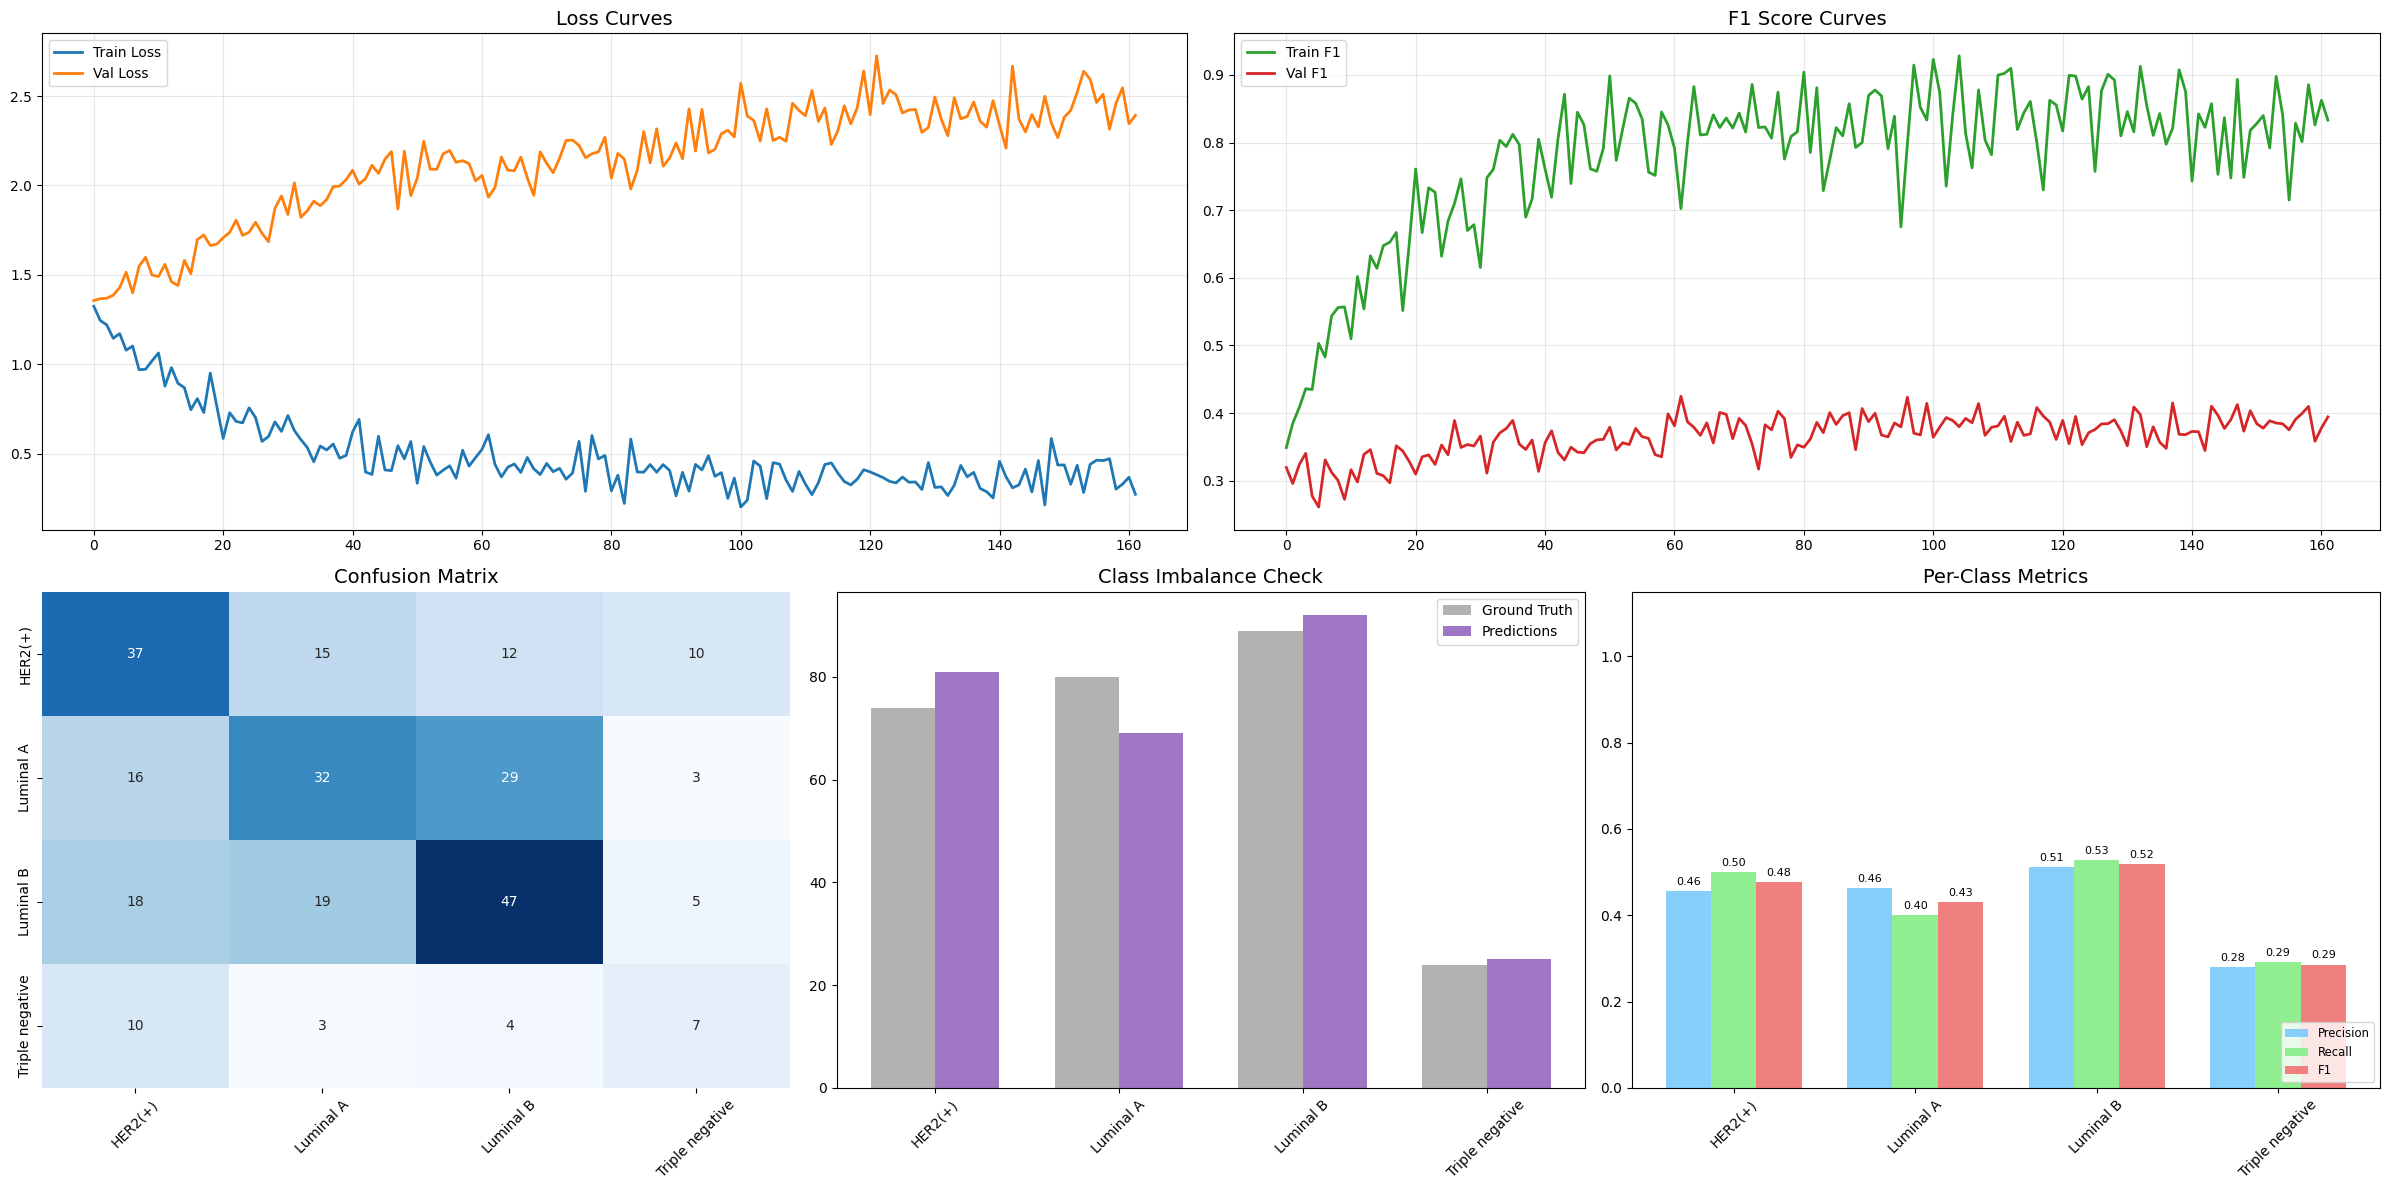

In [188]:
from sklearn.metrics import precision_recall_fscore_support

def plot_comprehensive_results(model, loader, device, label_encoder, history=None):
    """
    Plots:
    Row 1: Training History (Loss & F1)
    Row 2: Confusion Matrix | Class Distribution | Per-Class Metrics

    Assumes:
      - loader yields (inputs, labels) with inputs of shape (B, C, H, W)
        already transformed (e.g., normalized) as in your val DataLoader.
    """
    print("Generating comprehensive evaluation plots (patch-level)...")
    
    # --- 1. Get Predictions ---
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            inputs = val_transforms(inputs)

            # Direct forward; no extra transforms here
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_targets.extend(labels.cpu().numpy())
    
    all_preds    = np.array(all_preds)
    all_targets  = np.array(all_targets)
    class_names  = label_encoder.classes_
    
    # --- 2. Setup Figure Grid ---
    fig = plt.figure(figsize=(24, 12)) 
    gs = fig.add_gridspec(2, 6) 

    # =======================================================
    # ROW 1: HISTORY
    # =======================================================
    if history:
        ax1 = fig.add_subplot(gs[0, 0:3])
        ax1.plot(history['train_loss'], label='Train Loss', color='tab:blue', linewidth=2)
        ax1.plot(history['val_loss'],   label='Val Loss',   color='tab:orange', linewidth=2)
        ax1.set_title("Loss Curves", fontsize=14)
        ax1.legend(); ax1.grid(True, alpha=0.3)
        
        ax2 = fig.add_subplot(gs[0, 3:6])
        ax2.plot(history['train_f1'], label='Train F1', color='tab:green', linewidth=2)
        ax2.plot(history['val_f1'],   label='Val F1',   color='tab:red',   linewidth=2)
        ax2.set_title("F1 Score Curves", fontsize=14)
        ax2.legend(); ax2.grid(True, alpha=0.3)
    else:
        ax1 = fig.add_subplot(gs[0, 0:3]); ax1.text(0.5, 0.5, "No History", ha='center')
        ax2 = fig.add_subplot(gs[0, 3:6]); ax2.text(0.5, 0.5, "No History", ha='center')

    # =======================================================
    # ROW 2: ANALYSIS
    # =======================================================
    # 1. Confusion Matrix
    ax3 = fig.add_subplot(gs[1, 0:2])
    cm = confusion_matrix(all_targets, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax3, cbar=False)
    ax3.set_title("Confusion Matrix", fontsize=14)
    ax3.tick_params(axis='x', rotation=45)

    # 2. Prediction Distribution
    ax4 = fig.add_subplot(gs[1, 2:4])
    unique_true, true_counts = np.unique(all_targets, return_counts=True)
    pred_counts_full = np.zeros(len(class_names), dtype=int)
    unique_pred, pred_counts = np.unique(all_preds, return_counts=True)
    for cls, count in zip(unique_pred, pred_counts):
        pred_counts_full[cls] = count
    
    true_counts_full = np.zeros(len(class_names), dtype=int)
    for cls, count in zip(unique_true, true_counts):
        true_counts_full[cls] = count

    x = np.arange(len(class_names))
    width = 0.35
    ax4.bar(x - width/2, true_counts_full, width, label='Ground Truth', color='gray', alpha=0.6)
    ax4.bar(x + width/2, pred_counts_full, width, label='Predictions', color='tab:purple', alpha=0.9)
    ax4.set_title("Class Imbalance Check", fontsize=14)
    ax4.set_xticks(x); ax4.set_xticklabels(class_names, rotation=45)
    ax4.legend()

    # 3. Per-Class Metrics
    ax5 = fig.add_subplot(gs[1, 4:6])
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, labels=range(len(class_names)), zero_division=0
    )
    
    x = np.arange(len(class_names))
    width = 0.25
    rects1 = ax5.bar(x - width, precision, width, label='Precision', color='#87CEFA')
    rects2 = ax5.bar(x,         recall,    width, label='Recall',    color='#90EE90')
    rects3 = ax5.bar(x + width, f1,        width, label='F1',        color='#F08080')

    ax5.set_title('Per-Class Metrics', fontsize=14)
    ax5.set_xticks(x); ax5.set_xticklabels(class_names, rotation=45)
    ax5.legend(loc='lower right', fontsize='small')
    ax5.set_ylim(0, 1.15)
    
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if height > 0.01:
                ax5.annotate(f'{height:.2f}',
                             xy=(rect.get_x() + rect.get_width() / 2, height),
                             xytext=(0, 3), textcoords="offset points",
                             ha='center', va='bottom', fontsize=8)
    autolabel(rects1); autolabel(rects2); autolabel(rects3)

    plt.tight_layout()
    plt.show()


# Call with your patch-level validation loader
plot_comprehensive_results(
    model=best_model,
    loader=val_loader,         
    device=device,
    label_encoder=label_encoder,
    history=history
)


#### Gradcam

In [189]:
import cv2
import numpy as np
import torch
import random

def gradcam_on_val(best_model, val_loader, device, target_layer_name=GRADCAM_TARGET_LAYER):
    best_model.eval()

    # ImageNet stats on GPU
    mean = torch.tensor(norm_mean).view(1, 3, 1, 1).to(device)
    std  = torch.tensor(norm_std).view(1, 3, 1, 1).to(device)

    NUM_SAMPLES = GRADCAM_NUM_SAMPLES_VAL
    viz_images_list = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)

            # 1) Apply the SAME normalization as in validate_one_epoch (GPU)
            inputs = val_transforms(inputs)

            # 2) De-normalize back to [0,1] for visualization and Grad-CAM
            inputs_denorm = (inputs * std + mean).clamp(0.0, 1.0).cpu()  # (B,3,H,W)

            idxs = list(range(inputs_denorm.size(0)))
            random.shuffle(idxs)
            idxs = idxs[:NUM_SAMPLES]

            for i in idxs:
                viz_images_list.append(inputs_denorm[i])

            break  # only first batch is enough

    if len(viz_images_list) == 0:
        print("Error: valloader is empty, cannot generate Grad-CAM.")
        return

    viz_tensor = torch.stack(viz_images_list)  # (N,3,H,W)
    viz_masks_arr = None  # no lesion masks in this pipeline

    print(f"Visualizing {viz_tensor.shape[0]} validation patches with Grad-CAM...")

    visualize_gradcam_universal(
        model=best_model,
        images_tensor=viz_tensor,     # raw [0,1] on CPU, per-sample
        masks_numpy=viz_masks_arr,
        device=device,
        num_samples=viz_tensor.shape[0],
        target_layer_name=target_layer_name,
    )


## Test Prediction

In [190]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F


# -----------------------------
# Test patch dataset (no labels)
# -----------------------------
# -----------------------------
# Test patch dataset (no labels)
# -----------------------------
class TestPatchDataset(Dataset):
    def __init__(self, csv_path, root_dir, transform=None, use_masked_img=True):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.transform = transform
        self.use_masked_img = use_masked_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["patch_filename"]

        # Mirror PatchDataset logic so test uses same type of patches
        if self.use_masked_img:
            # want masked_ -> if CSV has raw, convert; if already masked, keep
            if not filename.startswith("masked_"):
                filename = filename.replace("img_", "masked_img_")
        else:
            # want raw -> if CSV has masked_, convert to img_
            if filename.startswith("masked_"):
                filename = filename.replace("masked_img_", "img_")

        patch_path = os.path.join(self.root_dir, filename)
        img_bgr = cv2.imread(patch_path)
        if img_bgr is None:
            raise ValueError(f"Could not read test patch {patch_path}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)

        if self.transform is not None:
            img = self.transform(img_pil)   # just ToTensor
        else:
            img = tv_transforms.ToTensor()(img_pil)

        image_id = str(row["image_id"])
        return img, image_id

# Use the SAME USE_MASKED_IMAGES flag as for train/val
test_patches_ds = TestPatchDataset(
    TEST_PATCH_CSV,
    TEST_PATCHES_DIR,
    transform=cpu_to_tensor,
    use_masked_img=USE_MASKED_IMAGES,
)

test_patches_loader = DataLoader(
    test_patches_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)


print(f"Test patches: {len(test_patches_ds)}")

# How many distinct images in the CSV
df_test_patches = pd.read_csv(TEST_PATCH_CSV)
unique_image_ids_csv = df_test_patches["image_id"].astype(str).nunique()
print(f"Unique test images listed in CSV: {unique_image_ids_csv}")

# -----------------------------
# Predict and mean probabilities per image_id
# -----------------------------
best_model.eval()
probs_by_image = {}  # image_id -> list of prob vectors

with torch.no_grad():
    for inputs, image_ids in test_patches_loader:
        inputs = inputs.to(device)
        inputs = val_transforms(inputs)   # GPU normalization
        logits = best_model(inputs)
        probs  = F.softmax(logits, dim=1)  # (B, C)

        probs_np = probs.cpu().numpy()
        for i, img_id in enumerate(image_ids):
            if img_id not in probs_by_image:
                probs_by_image[img_id] = []
            probs_by_image[img_id].append(probs_np[i])

# -----------------------------
# Aggregate (mean prob) and build submission
# -----------------------------
import numpy as np

rows = []
for img_id in sorted(probs_by_image.keys(), key=lambda x: int(x)):
    # probs_by_image[img_id] is a list of (C,) probability vectors
    probs_stack = torch.tensor(probs_by_image[img_id])   # (N_patches, C)

    # 1) Mean probabilities over patches
    probs_mean = probs_stack.mean(dim=0).numpy()         # (C,)

    # 2) Argmax on mean probs
    pred_idx = int(probs_mean.argmax())

    # 3) Map back to label string
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    # Ensure zero‑padded 4‑digit ID: img_0001.png
    img_id_int = int(img_id)
    sample_index = f"img_{img_id_int:04d}.png"
    rows.append((sample_index, pred_label))

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs(SUBMIT_DIR, exist_ok=True)

submission_path = os.path.join(SUBMIT_DIR, f"submission_{timestamp}.csv")

submission_df = pd.DataFrame(rows, columns=["sample_index", "label"])
submission_df.to_csv(submission_path, index=False)

print("Saved submission.csv")
print(submission_df.head())



Test patches: 1776
Unique test images listed in CSV: 477
Saved submission.csv
   sample_index      label
0  img_0000.png  Luminal B
1  img_0001.png  Luminal B
2  img_0002.png  Luminal B
3  img_0003.png  Luminal B
4  img_0004.png  Luminal B


#### Test Gradcam

In [191]:
def gradcam_on_test(best_model, test_patches_loader, device, target_layer_name="layer3"):
    best_model.eval()

    mean = torch.tensor(norm_mean).view(1, 3, 1, 1).to(device)
    std  = torch.tensor(norm_std).view(1, 3, 1, 1).to(device)

    NUM_SAMPLES = 8
    viz_images_list = []

    with torch.no_grad():
        for inputs, image_ids in test_patches_loader:
            inputs = inputs.to(device)

            # 1) Apply SAME normalization as in test prediction (GPU)
            inputs = val_transforms(inputs)

            # 2) De-normalize for visualization/Grad-CAM
            inputs_denorm = (inputs * std + mean).clamp(0.0, 1.0).cpu()

            idxs = list(range(inputs_denorm.size(0)))
            random.shuffle(idxs)
            idxs = idxs[:NUM_SAMPLES]

            for i in idxs:
                viz_images_list.append(inputs_denorm[i])

            break

    if len(viz_images_list) == 0:
        print("Error: test_patches_loader is empty, cannot generate Grad-CAM.")
        return

    viz_tensor = torch.stack(viz_images_list)
    viz_masks_arr = None  # no masks for test

    print(f"Visualizing {viz_tensor.shape[0]} test patches with Grad-CAM...")

    visualize_gradcam_universal(
        model=best_model,
        images_tensor=viz_tensor,
        masks_numpy=viz_masks_arr,
        device=device,
        num_samples=viz_tensor.shape[0],
        target_layer_name=target_layer_name,
    )


#### Test Results


Checking Prediction Balance...


/tmp/ipykernel_8536/3581754478.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


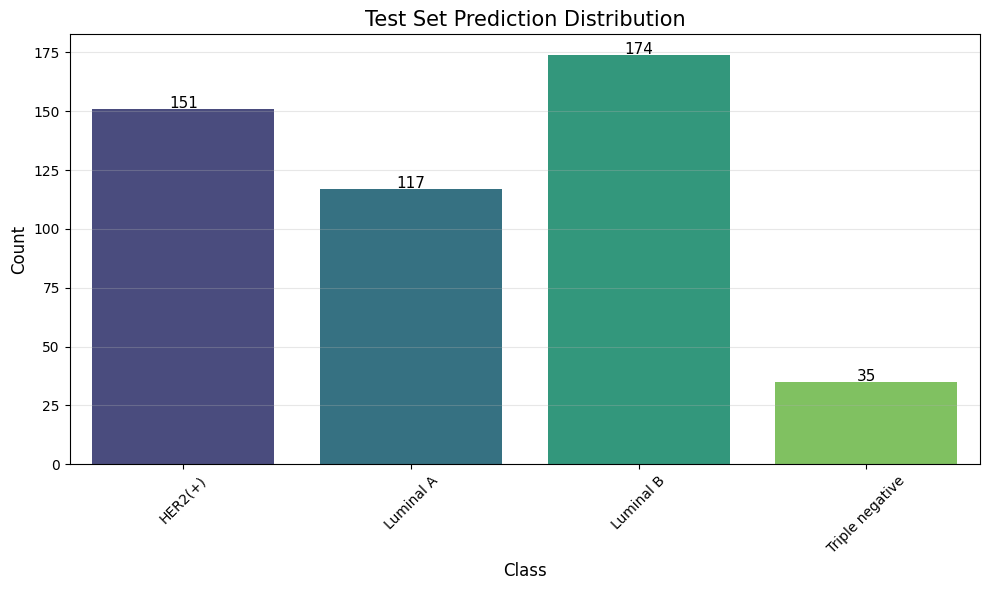

In [192]:
def plot_test_distribution(submission_df):
    plt.figure(figsize=(10, 6))
    
    # Count the predicted labels
    counts = submission_df["label"].value_counts().sort_index()
    
    # Plot bar chart
    ax = sns.barplot(
        x=counts.index,
        y=counts.values,
        palette="viridis"
    )
    
    plt.title("Test Set Prediction Distribution", fontsize=15)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)
    
    # Add numbers on top of bars
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha="center", fontsize=11)
        
    plt.tight_layout()
    plt.show()


# After you've built submission_df
print("\nChecking Prediction Balance...")
plot_test_distribution(submission_df)
